In [1]:
import sys
sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

import utils_2Q_gate_zp as ut

# First look at just the Pulse

In [2]:
buffer = 5
drive_amp = 1
drive_freq = 3
tg = 20
tlist = np.linspace(-buffer*tg, (buffer+1)*tg,  num=int(1000*tg))  # total time


## Gaussian Pulse, no DRAG

In [3]:
# For reference
# def drive_gauss_A(t: float, args: dict) -> float:
#     A = args.get('drive_amp_A', 0)
#     wd = args.get('drive_freq_A', 0)
#     tg = args.get('gate_time', 0)
#     return A * (np.exp(-8 * t * (t - tg) / tg**2) - 1) * np.cos(wd * t) * (0<=t<=tg)

In [4]:
pulse_args = {'drive_amp_A': drive_amp,
            'drive_freq_A': drive_freq,
            'gate_time': tg}
pulse = np.array([ut.drive_gauss_A(t, pulse_args) for t in tlist])

# Power spectrum of pulse
mag = np.fft.fftshift(np.abs(np.fft.fft(pulse)))
freqs = np.fft.fftshift(np.fft.fftfreq(pulse.size, tlist[1]-tlist[0]))
peak_loc = np.argmin(np.abs(freqs-drive_freq/(2*np.pi)))
ps_db = 20*np.log10(mag/mag[peak_loc])

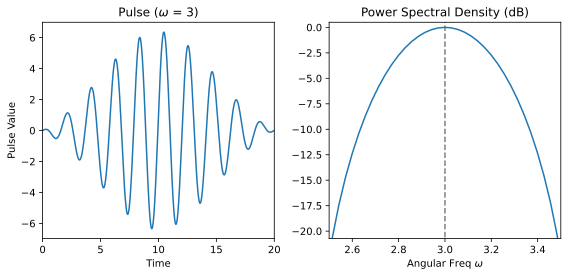

In [5]:
# Plot spectrum and pulse
f, ax = plt.subplots(ncols = 2, figsize=(8, 4))
ax[0].plot(tlist, pulse)
ax[0].set_xlim(0, tg)
ax[1].vlines(drive_freq, -100, 1, colors = "gray", linestyles = "--")
ax[1].plot(2*np.pi*freqs, ps_db)
delta = 0.5
xlim = [drive_freq - delta, drive_freq + delta]
ax[1].set_xlim(*xlim)
ax[1].set_ylim(np.min(ps_db[np.argmin(np.abs(2*np.pi*freqs-xlim[0])):peak_loc]),
               0.5+ps_db[peak_loc])
ax[0].set_title(f"Pulse ($\omega$ = {np.round(drive_freq, 2)})")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Pulse Value")
ax[1].set_title("Power Spectral Density (dB)")
ax[1].set_xlabel(r"Angular Freq $\omega$")
plt.tight_layout();

### Checking vs analytic FT

We don't have exactly a Gaussian (+ numerics) so it should be close, but not exact. Our envelope equation is:

$$
V_G (t) = \exp[-\frac{8 t (t-t_g)}{t_g^2}] - 1 = \exp[-\frac{(t - t_g/2)^2}{2 (t_g/4)^2}]\cdot\exp[2] - 1.
$$

So it is a Gaussian with std $\sigma = t_g/4$, centered at $\mu = t_g/2$, multiplied by a constant factor $e^{2} \approx 7.4$. The $-1$ is so that $V_G(0) = V_G(t_g) = 0$, as

$$
\exp[-\frac{8 \cdot 0 \cdot (0-t_g)}{t_g^2}] = \exp[-\frac{8 t_g (t_g-t_g)}{t_g^2}] = 1.
$$

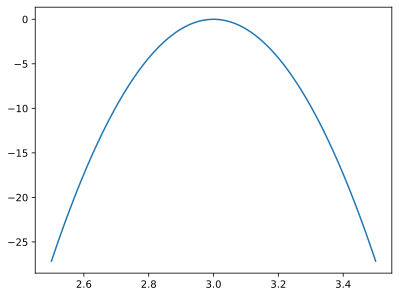

In [6]:
tau = tg/4
omega0 = drive_freq
omega = np.linspace(xlim[0], xlim[1], 100000)
expected = np.exp(-(((omega-omega0)*tau)**2)/2)
plt.plot(omega, 20*np.log10(expected/expected.max()))

## Simple DRAG

For a DRAG pulse, we add an additional term:

$$
V(t) = V_G(t)\cos(\omega_d t) + \alpha V_G'(t)\sin(\omega_d t),
$$

with 

$$
V_G'(t) = \frac{d}{dt}V_G(t) = \frac{d}{dt}(\exp[-\frac{8 t (t-t_g)}{t_g^2}] - 1) = \frac{t_g - 2t}{t_g^2}\exp[-\frac{8 t (t-t_g)}{t_g^2}]
$$

This creates a notch filter in frequency at $w_{notch} = w_d-1/\alpha$. Let's try to place the notch on the previous pulse at $\omega = 3.2$

In [7]:
dt = tlist[1]-tlist[0]
Delta = 0.2
lam = 1
pulse_args = {'drive_amp_A': drive_amp,
            'drive_freq_A': drive_freq,
            'gate_time': tg,
            'dt': dt,
            'alpha_A': -1/(Delta)
            }

In [8]:
# For reference in utils
# def drag_A(t: float, args: dict) -> float:
#     A = args.get('drive_amp_A', 0)
#     wd = args.get('drive_freq_A', 0)
#     tg = args.get('gate_time', 0)
#     alpha = args.get('alpha_A', 0)
#     vg = A * (np.exp(-8 * t * (t - tg) / tg**2) - 1)
#     return  vg* np.cos(wd* t)* (0<=t<=tg) + alpha* vg* (-8*(2*t-tg)/tg**2)* np.sin(wd* t)* (0<=t<=tg)
def drag_A(t: float, args: dict) -> float:
    A = args.get('drive_amp_A', 0)
    wd = args.get('drive_freq_A', 0)
    tg = args.get('gate_time', 0)
    alpha = args.get('alpha_A', 0)
    vg = A * (np.exp(-8 * t * (t - tg) / tg**2) - 1)
    # The + A in the second term is new
    return  vg* np.cos(wd* t)* (0<=t<=tg) + alpha* (vg + A) * (-8*(2*t-tg)/tg**2)* np.sin(wd* t)* (0<=t<=tg)

### Drag coefficient over time

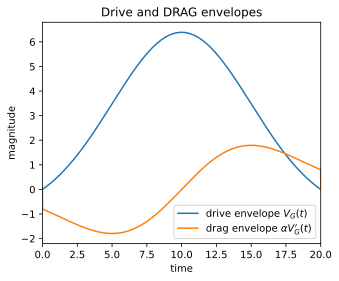

In [9]:
vg = drive_amp * (np.exp(-8 * tlist * (tlist - tg) / tg**2) - 1) * np.logical_and(0<=tlist, tlist<=tg)
drag_coeff = (-1/delta)* (vg + drive_amp) * (-8*(2*tlist-tg)/tg**2) * np.logical_and(0<=tlist, tlist<=tg)
lam = 1
drag_detuning = (lam**2 - 4)*(vg**2)/(4*delta)

f, ax = plt.subplots(ncols=1, figsize=(5,4))

ax = [ax]

ax[0].plot(tlist, vg*np.ones_like(tlist), label=r"drive envelope $V_G(t)$")
ax[0].plot(tlist, drag_coeff, label=r"drag envelope $\alpha V_G'(t)$")
# ax[0].plot(tlist, drag_detuning, label=r"drag detuning $\delta(t)$")
ax[0].set_xlabel("time")
ax[0].set_ylabel("magnitude")
ax[0].set_xlim(0, tg)
ax[0].set_title("Drive and DRAG envelopes")

# ax[1].plot(tlist, Omega_x_p, label=r"$\Omega_x'(t)$")
# ax[1].plot(tlist, Omega_y_p, label=r"$\Omega_y'(t)$")
# ax[1].set_xlim(0, tg)
# ax[1].set_title("Modulated DRAG Coefficients")
# ax[1].legend()

ax[0].legend();


In [10]:
print("pulse areas V_G:", np.sum(vg*dt), "DRAG", np.sum(drag_coeff*dt))

pulse areas V_G: 68.39439634353096 DRAG 1.0658141036401503e-14


It is worth noting that the drag envelope values are on the same order as the main drive envelope

### Do the pulse

In [11]:
# pulse_drag = np.array([ut.drag_A(t, pulse_args) for t in tlist])
pulse_drag = np.array([drag_A(t, pulse_args) for t in tlist])

# Power spectrum of pulse
mag_drag = np.fft.fftshift(np.abs(np.fft.fft(pulse_drag)))
freqs_drag = np.fft.fftshift(np.fft.fftfreq(pulse_drag.size, tlist[1]-tlist[0]))
ps_db_drag = 20*np.log10(mag_drag/mag[peak_loc])


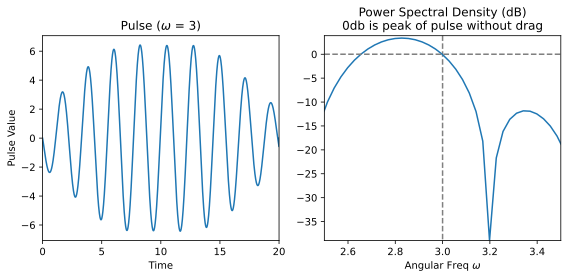

In [12]:
# Plot spectrum and pulse
f, ax = plt.subplots(ncols = 2, figsize=(8, 4))
ax[0].plot(tlist, pulse_drag)
ax[0].set_xlim(0, tg)
ax[1].vlines(drive_freq, -100, 10, colors = "gray", linestyles = "--")
ax[1].plot(2*np.pi*freqs_drag, ps_db_drag)
delta = 0.5
xlim = [drive_freq - delta, drive_freq + delta]
xstart = np.argmin(np.abs(2*np.pi*freqs_drag-xlim[0]))
xend = np.argmin(np.abs(2*np.pi*freqs_drag-xlim[1]))
ax[1].set_xlim(*xlim)
ax[1].hlines(0, xlim[0], xlim[1], colors = "gray", linestyles = "--")
ax[1].set_ylim(np.min(ps_db_drag[xstart:xend]),
               0.5+np.max(ps_db_drag[xstart:xend]))
ax[0].set_title(f"Pulse ($\omega$ = {np.round(drive_freq, 2)})")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Pulse Value")
ax[1].set_title("Power Spectral Density (dB)\n0db is peak of pulse without drag")
ax[1].set_xlabel(r"Angular Freq $\omega$")
plt.tight_layout();

## "Y-Only" Solution for DRAG

According to https://journals.aps.org/pra/abstract/10.1103/PhysRevA.83.012308, they formulate DRAG as trying to find a control signal

$$
V(t) = \Omega_x(t) \cos(\omega_d t) + \Omega_y(t) \sin(\omega_d t)
$$

such that the dynamics of a 3 or more level atom is reduced to 2 levels. In general, DRAG also relies on a $\delta(t)$ parameter which represents a tunable qubit frequency, although it is possible to formulate this as a phase ramping of the control signal (see next section). It also references an anharmonicity $\Delta$ parameter and relative drive strength $\lambda$ parameter.

$$
\Delta_j = \omega_{0j} - j\omega_{01} ,
$$

with $\omega_{ij}$ being the transition between energy levels $i$ and $j$. In the case of Transmon-like systems, we are concerned with $\Delta_2$ = $\omega_{02} - 2\omega_{01}$ = $\omega_{12} - \omega_{10}$. For $\lambda$, we have:

$$
\lambda_j = \frac{|\langle j| H_{control} |j+1\rangle|}{|\langle 0| H_{control} |1\rangle|}
$$

being the relative strength of the control Hamiltonian between the intended transition and the one being supressed.

It is often convenient to focus on the so-called "Y-Only" family of solutions, where $\Omega_x(t) = \Omega_G(t)$, a Gaussian pulse, and $\delta(t) = 0$. Up to first order for a transmon-like system, the Y-Only solution is:

$$
\Omega_x(t) = \Omega_G(t)
$$

$$
\Omega_y(t) = -\frac{\lambda_1^2 \dot{\Omega}_G(t)}{4 \Delta_2}
$$

$$
\delta(t) = 0
$$


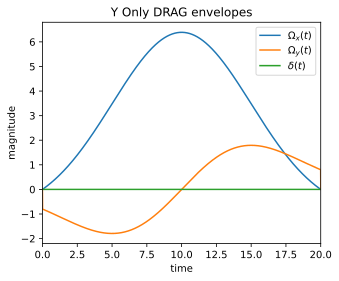

In [13]:
Omega_x = drive_amp * (np.exp(-8 * tlist * (tlist - tg) / tg**2) - 1) * np.logical_and(0<=tlist, tlist<=tg)
lam = 1
Delta = 0.2
Omega_y = lam*(-0.25/Delta)* (vg + drive_amp) * (-8*(2*tlist-tg)/tg**2) * np.logical_and(0<=tlist, tlist<=tg)
detune = np.zeros_like(Omega_y)

f, ax = plt.subplots(ncols=1, figsize=(5, 4))
ax.plot(tlist, vg*np.ones_like(tlist), label=r"$\Omega_x(t)$")
ax.plot(tlist, drag_coeff, label=r"$\Omega_y(t)$")
ax.plot(tlist, detune, label=r"$\delta(t)$")
ax.set_xlabel("time")
ax.set_ylabel("magnitude")
ax.set_xlim(0, tg)
ax.set_title("Y Only DRAG envelopes")
plt.legend();

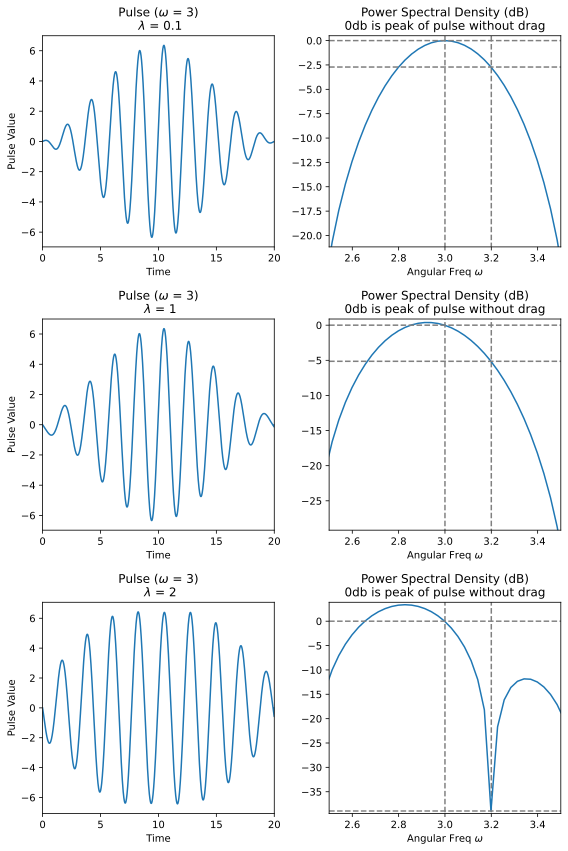

In [14]:

# Plot spectrum and pulse
lam_vec = [0.1, 1, 2]
nrows = len(lam_vec)
f, ax = plt.subplots(ncols = 2, nrows=nrows, figsize=(8, nrows*4))

for i, lam in enumerate(lam_vec):

    Delta = 0.2
    pulse_args = {'drive_amp_A': drive_amp,
                'drive_freq_A': drive_freq,
                'gate_time': tg,
                'dt': dt,
                'alpha_A': -(lam**2)/(4*Delta)
                }

    pulse_drag = np.array([drag_A(t, pulse_args) for t in tlist])

    # Power spectrum of pulse
    mag_drag = np.fft.fftshift(np.abs(np.fft.fft(pulse_drag)))
    freqs_drag = np.fft.fftshift(np.fft.fftfreq(pulse_drag.size, tlist[1]-tlist[0]))
    ps_db_drag = 20*np.log10(mag_drag/mag[peak_loc])



    ax[i, 0].plot(tlist, pulse_drag)
    ax[i, 0].set_xlim(0, tg)
    ax[i,1].vlines(drive_freq, -100, 10, colors = "gray", linestyles = "--")
    ax[i,1].vlines(drive_freq+Delta, -100, 10, colors = "gray", linestyles = "--")
    ax[i,1].plot(2*np.pi*freqs_drag, ps_db_drag)
    delta = 0.5
    xlim = [drive_freq - delta, drive_freq + delta]
    xstart = np.argmin(np.abs(2*np.pi*freqs_drag-xlim[0]))
    xend = np.argmin(np.abs(2*np.pi*freqs_drag-xlim[1]))
    ax[i,1].set_xlim(*xlim)
    ax[i,1].hlines(0, xlim[0], xlim[1], colors = "gray", linestyles = "--")
    ax[i,1].hlines(ps_db_drag[np.argmin(np.abs(2*np.pi*freqs_drag-(drive_freq+Delta)))], 
                   xlim[0], xlim[1], colors = "gray", linestyles = "--")
    ax[i,1].set_ylim(np.min(ps_db_drag[xstart:xend])-0.5,
                0.5+np.max(ps_db_drag[xstart:xend]))
    ax[i,0].set_title(f"Pulse ($\omega$ = {np.round(drive_freq, 2)})\n $\lambda$ = {lam}")
    ax[i,0].set_xlabel("Time")
    ax[i,0].set_ylabel("Pulse Value")
    ax[i,1].set_title("Power Spectral Density (dB)\n0db is peak of pulse without drag")
    ax[i,1].set_xlabel(r"Angular Freq $\omega$")
    plt.tight_layout();

All in all it seems like a balancing act between the strength of the competing matrix element and how close the transition is. This dictates where to position the notch/shift the bulk.

## Optimal First Order DRAG -- UNFINISHED

According to https://journals.aps.org/pra/abstract/10.1103/PhysRevA.83.012308, for optimal first order DRAG, we take:

$$
\Omega_x(t) = \Omega_G(t)
$$

$$
\Omega_y(t) = -\frac{\dot{\Omega}_G(t) \lambda }{2 \Delta}
$$

$$
\delta(t) = -(\lambda^2 - 2 \lambda)\frac{\Omega_G^2(t) \lambda }{4 \Delta}
$$

Here $\lambda$ is the relative strength of the drive matrix element you are trying to suppress, relative to the one you are trying to drive. $\Delta$ is the detuning of your carrier frequency from the leakage frequency $\omega_d - \omega_\lambda$. For DRAG, usually $\delta$ is assumed to be change in the qubit frequency, although it is possible to formulate this as a phase ramping of the control signal:

$$
V(t) = \Omega_x'(t) \cos(\omega_d t) + \Omega_y'(t)\sin(\omega_d t)
$$

with

$$
\Omega_x'(t)  = \Omega_x(t)\cos(\int_0^t \delta(s) ds) + \Omega_y(t)\sin(\int_0^t \delta(s) ds)
$$

and

$$
\Omega_y'(t) = \Omega_y(t)\cos(\int_0^t \delta(s) ds) - \Omega_x(t) \sin(\int_0^t \delta(s) ds)
$$

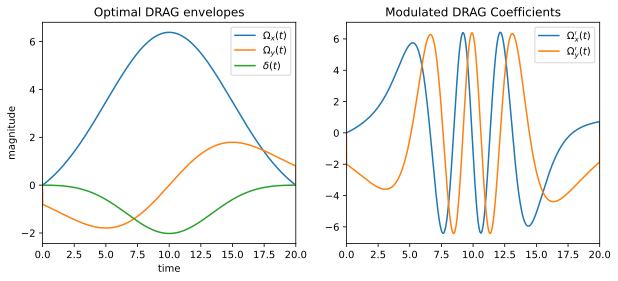

In [15]:
Omega_x = drive_amp * (np.exp(-8 * tlist * (tlist - tg) / tg**2) - 1) * np.logical_and(0<=tlist, tlist<=tg)
lam = 1.99
Delta = 0.2
Omega_y = lam*(-0.5/Delta)* (vg + drive_amp) * (-8*(2*tlist-tg)/tg**2) * np.logical_and(0<=tlist, tlist<=tg)
detune = (lam**2 - 2*lam)*lam*(vg**2)/(4*Delta)

Omega_x_p = Omega_x*np.cos(np.cumsum(detune*dt)) + Omega_y*np.sin(np.cumsum(detune*dt))
Omega_y_p = Omega_y*np.cos(np.cumsum(detune*dt)) - Omega_x*np.sin(np.cumsum(detune*dt))

f, ax = plt.subplots(ncols=2, figsize=(10, 4))
ax[0].plot(tlist, vg*np.ones_like(tlist), label=r"$\Omega_x(t)$")
ax[0].plot(tlist, drag_coeff, label=r"$\Omega_y(t)$")
ax[0].plot(tlist, detune, label=r"$\delta(t)$")
ax[0].set_xlabel("time")
ax[0].set_ylabel("magnitude")
ax[0].set_xlim(0, tg)
ax[0].set_title("Optimal DRAG envelopes")

ax[1].plot(tlist, Omega_x_p, label=r"$\Omega_x'(t)$")
ax[1].plot(tlist, Omega_y_p, label=r"$\Omega_y'(t)$")
ax[1].set_xlim(0, tg)
ax[1].set_title("Modulated DRAG Coefficients")
ax[1].legend()

ax[0].legend();

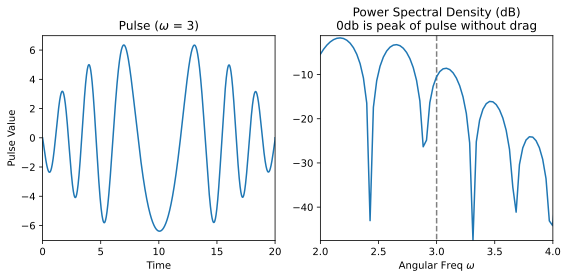

In [16]:
# Power spectrum of pulse

pulse_drag = drive_amp*(Omega_x_p*np.cos(drive_freq*tlist) + Omega_y_p*np.sin(drive_freq*tlist))

mag_drag = np.fft.fftshift(np.abs(np.fft.fft(pulse_drag)))
freqs_drag = np.fft.fftshift(np.fft.fftfreq(pulse_drag.size, tlist[1]-tlist[0]))
ps_db_drag = 20*np.log10(mag_drag/mag[peak_loc])

# Plot spectrum and pulse
f, ax = plt.subplots(ncols = 2, figsize=(8, 4))
ax[0].plot(tlist, pulse_drag)
ax[0].set_xlim(0, tg)
ax[1].vlines(drive_freq, -100, 10, colors = "gray", linestyles = "--")
ax[1].plot(2*np.pi*freqs_drag, ps_db_drag)
delta = 1.0
xlim = [drive_freq - delta, drive_freq + delta]
xstart = np.argmin(np.abs(2*np.pi*freqs_drag-xlim[0]))
xend = np.argmin(np.abs(2*np.pi*freqs_drag-xlim[1]))
ax[1].set_xlim(*xlim)
ax[1].hlines(0, xlim[0], xlim[1], colors = "gray", linestyles = "--")
ax[1].set_ylim(np.min(ps_db_drag[xstart:xend]),
               0.5+np.max(ps_db_drag[xstart:xend]))
ax[0].set_title(f"Pulse ($\omega$ = {np.round(drive_freq, 2)})")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Pulse Value")
ax[1].set_title("Power Spectral Density (dB)\n0db is peak of pulse without drag")
ax[1].set_xlabel(r"Angular Freq $\omega$")
plt.tight_layout();


# Quantum Toy Model

First do Transmon-like

In [17]:
w01 = 30
w12 = 30.5
H0 = w01*qt.basis(3, 1).proj() + (w01+w12)*qt.basis(3, 2).proj()
H0

Quantum object: dims = [[3], [3]], shape = (3, 3), type = oper, isherm = True
Qobj data =
[[ 0.   0.   0. ]
 [ 0.  30.   0. ]
 [ 0.   0.  60.5]]

In [18]:
lam = 1
H1 = lam*(qt.basis(3, 1)*qt.basis(3, 0).dag() + qt.basis(3, 2)*qt.basis(3, 1).dag())
H1 = H1 + H1.dag()
H1

Quantum object: dims = [[3], [3]], shape = (3, 3), type = oper, isherm = True
Qobj data =
[[0. 1. 0.]
 [1. 0. 1.]
 [0. 1. 0.]]

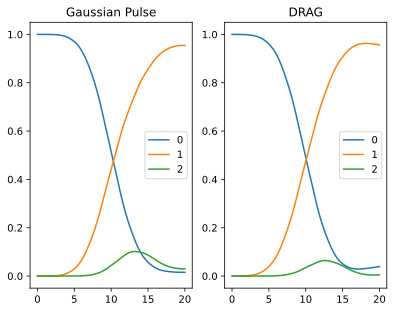

In [19]:
e_ops = [qt.basis(3,i).proj() for i in range(3)]
H_qbt_drive = [H0, [H1,ut.drive_gauss_A]]
H_qbt_drive_drag = [H0, [H1,drag_A]]
t_list = np.linspace(0, tg, 200)
delta = 0.2
# Drive amp to do a pi pulse if there were no third state np.pi/np.sum(vg*dt)
pulse_args = {'drive_amp_A': 0.0459,
            'drive_freq_A': w01,
            'gate_time': tg,
            'dt': dt,
            'alpha_A': -lam/(4*delta)
            }
# Evolve state from 0 under the drive with and without drag
options =qt.Options(num_cpus=4)
res = qt.sesolve(H=H_qbt_drive, psi0 = qt.basis(3, 0), tlist=t_list, args=pulse_args, e_ops=e_ops, options=options)
res_drag = qt.sesolve(H=H_qbt_drive_drag, psi0 = qt.basis(3, 0), tlist=t_list, args=pulse_args, e_ops=e_ops, options=options)

f, ax = plt.subplots(ncols=2)

for i, expect in enumerate(res.expect):
    ax[0].plot(t_list, res.expect[i], label=i)
    # ax[0].set_xlim(buffer*tg, buffer*tg+tg)
ax[0].legend()

for i, expect in enumerate(res_drag.expect):
    ax[1].plot(t_list, res_drag.expect[i], label=i)
    # ax[1].set_xlim(0, tg)
ax[1].legend()

ax[0].set_title("Gaussian Pulse")
ax[1].set_title("DRAG");

Much less population enters the intermediate state using DRAG vs. not using DRAG

# Old

In [20]:
# def drive_gauss_A(t: float, args: dict) -> float:
#     A = args.get('drive_amp_A', 0)
#     wd = args.get('drive_freq_A', 0)
#     tg = args.get('gate_time', 0)
#     return A * (np.exp(-8 * t * (t - tg) / tg**2)) * np.cos(wd * t)

# pulse_args = {'drive_amp_A': drive_amp,
#             'drive_freq_A': drive_freq,
#             'gate_time': tg}

# pulse = np.array([drive_gauss_A(t, pulse_args) for t in tlist])

In [21]:
# def drag_A(t: float, args: dict) -> float:
#     A = args.get('drive_amp_A', 0)
#     wd = args.get('drive_freq_A', 0)
#     tg = args.get('gate_time', 0)
#     alpha = args.get('alpha_A', 0)
#     dt = args.get('alpha_A', 0.00001)
#     vg = lambda t_: A * (np.exp(-8 * t_ * (t_ - tg) / tg**2) - 1) * (0<=t_<=tg)
#     return  vg(t) * np.cos(wd * t) + alpha * (vg(t+dt/2) - vg(t-dt/2))/dt * np.sin(wd * t)

In [22]:
# def drag_A(t: float, args: dict) -> float:
#     A = args.get('drive_amp_A', 0)
#     wd = args.get('drive_freq_A', 0)
#     gate_start = args.get('gate_start', 0)
#     tg = args.get('gate_time', 0)
#     alpha = args.get('alpha_A', 0)
#     t = t - gate_start
#     vg = A * (np.exp(-8 * t * (t - tg) / tg**2) - 1)
#     # The + A in the second term is new
#     return  vg* np.cos(wd* t)* (0<=t<=0+tg) + alpha* (vg + A) * (-8*(2*t-tg)/tg**2)* np.sin(wd* t)* (0<=t<=0+tg)

# def drive_gauss_A(t: float, args: dict) -> float:
#     A = args.get('drive_amp_A', 0)
#     wd = args.get('drive_freq_A', 0)
#     gate_start = args.get('gate_start', 0)
#     tg = args.get('gate_time', 0)
#     t = t - gate_start
#     return A * (np.exp(-8 * t * (t - tg) / tg**2) - 1) * np.cos(wd * t) * (0<=t<=0+tg)
#
# e_ops = [qt.basis(3,i).proj() for i in range(3)]
# H_qbt_drive = [H0, [H1,drive_gauss_A]]
# H_qbt_drive_drag = [H0, [H1,drag_A]]
# buffer = 0
# t_list = np.linspace(0, (2*buffer + 1)*tg, int((2*buffer+1)*200))
# delta = 0.2
# # Drive amp to do a pi pulse if there were no third state np.pi/np.sum(vg*dt)
# pulse_args = {'drive_amp_A': 0.0459,
#             'drive_freq_A': w01,
#             'gate_start': buffer*tg,
#             'gate_time': tg,
#             'dt': dt,
#             'alpha_A': -lam/(4*delta)
#             }
# # Evolve state from 0 under the drive with and without drag
# options =qt.Options(max_step=1e-04, nsteps=1e6, num_cpus=4)
# res = qt.sesolve(H=H_qbt_drive, psi0 = qt.basis(3, 0), tlist=t_list, args=pulse_args, e_ops=e_ops, options=options)
# res_drag = qt.sesolve(H=H_qbt_drive_drag, psi0 = qt.basis(3, 0), tlist=t_list, args=pulse_args, e_ops=e_ops, options=options)

# f, ax = plt.subplots(ncols=2)

# for i, expect in enumerate(res.expect):
#     ax[0].plot(t_list, res.expect[i], label=i)
#     # ax[0].set_xlim(buffer*tg, buffer*tg+tg)
# ax[0].legend()

# for i, expect in enumerate(res_drag.expect):
#     ax[1].plot(t_list, res_drag.expect[i], label=i)
#     # ax[1].set_xlim(0, tg)
# ax[1].legend()

# ax[0].set_title("Gaussian Pulse")
# ax[1].set_title("DRAG");